In [1]:
import numpy as np


def Poisson2D_5_Jacobi(a, b, g, f, m, tol, 
                       itermax = 1000, return_errors=False, warning=True):
    r"""
    """
    U = np.ones(shape=(m+2, m+2))
    U_new = np.zeros(shape=(m+2, m+2))
    h = (b-a)/(m+1)
    X = np.linspace(a, b, m+2)
    Y = np.linspace(a, b, m+2)
    # Define boundaries
    for k in range(m+2):
        U[0, k] = g(X[0], Y[k])
        U[m+1, k] = g(X[m+1],Y[k])
        U[k, 0] = g(X[k],Y[0])
        U[k, m+1] = g(X[k],Y[m+1])

    error = -1
    errorsk = []

    k = 0
    while (error > tol or error == -1) and k < itermax:
        for i in range(1,m+1):
            for j in range(1, m+1):
                U_new[i, j] = 0.25 * (U[i-1, j] + U[i+1, j] + U[i, j-1] + U[i, j+1] 
                                    - h**2 * f(X[i], Y[j]))
                
        error = np.max(abs(U_new - U))
        if return_errors:
            errorsk.append(error)
        U = U_new.copy()
        k += 1
    if k>=itermax and warning:
        print("ITERMAX REACHED")

    grid = np.array([[X[i], Y[j]] for i in range(m+2) for j in range(m+2)])
    Uv = np.array([U[i, j] for i in range(m+2) for j in range(m+2)])

    if return_errors:
        return grid, Uv, errorsk
    
    return grid, Uv

def Poisson2D_5_GS(a, b, g, f, m, tol, 
                   itermax = 1000, return_errors=False, warning=True):
    r"""
    """
    U = np.ones(shape=(m+2, m+2))
    h = (b-a)/(m+1)
    X = np.linspace(a, b, m+2)
    Y = np.linspace(a, b, m+2)
    # Define boundaries
    for k in range(m+2):
        U[0, k] = g(X[0], Y[k])
        U[m+1, k] = g(X[m+1],Y[k])
        U[k, 0] = g(X[k],Y[0])
        U[k, m+1] = g(X[k],Y[m+1])

    error = -1
    errorsk = []

    k = 0
    while (error > tol or error == -1) and k < itermax:
        error = -1
        for i in range(1,m+1):
            for j in range(1, m+1):
                u_ij_new = 0.25 * (U[i-1, j] + U[i+1, j] + U[i, j-1] + U[i, j+1] 
                                    - h**2 * f(X[i], Y[j]))
                
                error = np.max([error, abs(u_ij_new - U[i, j])])
                U[i,j] = u_ij_new
        
        if return_errors:
            errorsk.append(error)
        k += 1

    if k>=itermax and warning:
        print("ITERMAX REACHED")
    
    grid = np.array([[X[i], Y[j]] for i in range(m+2) for j in range(m+2)])
    Uv = np.array([U[i, j] for i in range(m+2) for j in range(m+2)])

    if return_errors:
        return grid, Uv, errorsk
    return grid, Uv

def Poisson2D_5_SOR(a, b, g, f, m, tol, 
                    w=1, itermax = 1000, return_errors=False, warning=True):
    r"""
    """
    U = np.zeros(shape=(m+2, m+2))
    h = (b-a)/(m+1)
    X = np.linspace(a, b, m+2)
    Y = np.linspace(a, b, m+2)
    # Define boundaries
    for k in range(m+2):
        U[0, k] = g(X[0], Y[k])
        U[m+1, k] = g(X[m+1],Y[k])
        U[k, 0] = g(X[k],Y[0])
        U[k, m+1] = g(X[k],Y[m+1])

    error = -1
    errorsk = []
    k=0
    while (error > tol or error == -1) and k < itermax:
        error = -1
        for i in range(1,m+1):
            for j in range(1, m+1):
                u_ij = 0.25 * (U[i-1, j] + U[i+1, j] + U[i, j-1] + U[i, j+1] 
                                    - h**2 * f(X[i], Y[j]))

                u_ij_sor = (1 - w)*U[i, j] + w * u_ij
                error = np.max([error, abs(u_ij_sor - U[i, j])])
                U[i,j] = u_ij_sor
        if return_errors:
            errorsk.append(error)
        k += 1
    if k>= itermax and warning:
        print("ITERMAX REACHED")

    grid = np.array([[X[i], Y[j]] for i in range(m+2) for j in range(m+2)])
    Uv = np.array([U[i, j] for i in range(m+2) for j in range(m+2)])

    if return_errors:
        return grid, Uv, errorsk
    return grid, Uv

In [2]:
import numpy as np


def jacobi_5point(U, f, h, tol, itermax):
    """
    Jacobi iteration for the 5-point finite difference scheme.

    U is assumed to satisfy the boundary conditions.
    """

    m = len(U) - 2

    U_new = U.copy()
    errors = []

    k = 0
    error = np.inf

    while error > tol and k < itermax:

        for i in range(1, m + 1):
            for j in range(1, m + 1):

                U_new[i, j] = 0.25 * (U[i - 1, j] + U[i + 1, j] + U[i, j - 1] + U[i, j + 1] - h**2 * f[i, j])

        error = np.max(np.abs(U_new - U))
        errors.append(error)

        U = U_new.copy()
        k += 1

    return U, errors


def gs_5point(U, f, h, tol, itermax):
    """
    Gauss-Seidel iteration for the 5-point finite difference scheme.

    U is assumed to satisfy the boundary conditions.
    """

    m = len(U) - 2

    errors = []

    k = 0
    error = np.inf

    while error > tol and k < itermax:

        U_old = U.copy()

        for i in range(1, m + 1):
            for j in range(1, m + 1):

                U[i, j] = 0.25 * (U[i - 1, j] + U[i + 1, j] + U[i, j - 1] + U[i, j + 1] - h**2 * f[i, j])

        error = np.max(np.abs(U - U_old))
        errors.append(error)

        k += 1

    return U, errors


def sor_5point(U, f, h, w, tol, itermax):
    """
    Successive Over-Relaxation (SOR) iteration for the
    5-point finite difference scheme.

    U is assumed to satisfy the boundary conditions.
    """

    m = len(U) - 2

    errors = []

    k = 0
    error = np.inf

    while error > tol and k < itermax:

        U_old = U.copy()

        for i in range(1, m + 1):
            for j in range(1, m + 1):

                U_gs = 0.25 * (U[i - 1, j] + U[i + 1, j] + U[i, j - 1] + U[i, j + 1] - h**2 * f[i, j])
                U[i, j] = U[i, j] + w * (U_gs - U[i, j])

        error = np.max(np.abs(U - U_old))
        errors.append(error)

        k += 1

    return U, errors

In [3]:
import numpy as np
import matplotlib.pyplot as plt


h = 1/20
m = 39

x = np.linspace(-1, 1, m + 2)
y = np.linspace(-1, 1, m + 2)


# Exact solution
u_exact = lambda x, y: np.exp(x) * np.sin(np.pi * y)

# Right-hand side
f = lambda x, y: (1 - np.pi**2) * u_exact(x, y)

# Exact solution on the grid
sol = np.zeros((m + 2, m + 2))
for i in range(m + 2):
    sol[i, :] = u_exact(x[i], y)


# Right-hand side on the grid
rhs = np.zeros((m + 2, m + 2))

for i in range(1, m + 1):
    rhs[i, 1:-1] = f(x[i], y[1:-1])


# Initial approximation satisfying the boundary conditions
u0_5point = np.zeros((m + 2, m + 2))


# Boundary conditions
u0_5point[0, :] = u_exact(x[0], y)
u0_5point[-1, :] = u_exact(x[-1], y)
u0_5point[:, 0] = u_exact(x, y[0])
u0_5point[:, -1] = u_exact(x, y[-1])

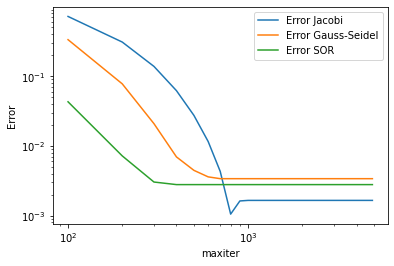

In [4]:
iters = [100 * k for k in range(1, 50)]

errors_Jacobi = []
errors_gs = []
errors_sor = []


for itermax in iters:

    u_jacobi, errors_j = jacobi_5point(u0_5point.copy(),rhs,h,tol=1e-5,itermax=itermax)

    u_gs, errors_g = gs_5point(u0_5point.copy(),rhs,h,tol=1e-5,itermax=itermax)

    u_sor, errors_s = sor_5point(u0_5point.copy(),rhs,h,w=1.5,tol=1e-5,itermax=itermax)

    errors_Jacobi.append(np.max(np.abs(u_jacobi - sol)))

    errors_gs.append(np.max(np.abs(u_gs - sol)))

    errors_sor.append(np.max(np.abs(u_sor - sol)))
    
plt.loglog(iters, errors_Jacobi, label="Error Jacobi")
plt.loglog(iters, errors_gs, label="Error Gauss-Seidel")
plt.loglog(iters, errors_sor, label="Error SOR")

plt.xlabel("maxiter")
plt.ylabel("Error")
plt.legend(loc="best")

plt.show()

In [5]:
u_jacobi, errors_j = jacobi_5point(
    u0_5point.copy(),
    rhs,
    h,
    tol=1e-5,
    itermax=1000
)

print("Error respecto a la solución exacta:")
print(np.max(np.abs(u_jacobi - sol)))

print("\nÚltimo error entre iteraciones:")
print(errors_j[-1])

print("\nNúmero de iteraciones realizadas:")
print(len(errors_j))

Error respecto a la solución exacta:
0.0016532590883955312

Último error entre iteraciones:
9.969037410018089e-06

Número de iteraciones realizadas:
905
